# Distribution Fitter

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/distribution-fitter/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/distribution-fitter/demo.ipynb)

> Fitting ten distributions and ranking them by AIC is four lines of scipy. The ranking will
> always produce a winner - including when the data came from something that is not in the
> list. **AIC answers a relative question and gets read as an absolute one.**

**What this covers**

1. The standard workflow, on data where it works
2. **The main event**: the KS p-value is wrong when you fit the parameters first
3. AIC's confident winner on data no candidate can describe
4. Support is a constraint, not a nuisance
5. What a free location parameter actually buys
6. Rounding, sample size, and rejecting the true family
7. Akaike weight vs bootstrap selection stability
8. The verdict the tool is entitled to print
9. Try your own column

*Fully offline - all data is generated, numpy + scipy + matplotlib only.*

## 0. Setup

The two modules are written to disk from embedded source, so this runs identically in Colab,
in Binder, and next to the repo.

In [1]:
import pathlib

FITTING_SRC = r'''"""Distribution fitting that reports whether anything actually fits.

`scipy.stats.<dist>.fit(x)` is one line, and AIC ranking is three more. The reason
distribution-fitting ships wrong answers is not the arithmetic - it is that every step of
the standard workflow answers a *relative* question and gets read as an *absolute* one.

Five mechanisms:

1. AIC ALWAYS PICKS A WINNER. Ranking by AIC tells you which candidate is least bad. It
   cannot tell you that all of them are bad. Data from a mixture, or a Gumbel, or anything
   outside the candidate set still produces a confident-looking table with a winner and an
   Akaike weight of 0.98. The absolute question needs its own test.
2. THE NAIVE KS P-VALUE IS WRONG WHEN YOU FIT THE PARAMETERS FIRST. `ks_1samp(x, dist.cdf,
   args=fitted)` assumes the parameters were known before seeing the data. Estimating them
   pulls the fitted CDF toward the sample, shrinking D, so the p-value is far too large and
   the test has almost no power. The fix is a parametric bootstrap that REFITS on every
   simulated sample (the Lilliefors construction, generalised).
3. SUPPORT IS A CONSTRAINT, NOT A NUISANCE. A lognormal cannot describe a column containing
   zero. Silently dropping the offending rows changes the data being compared, so the AIC is
   no longer on the same footing as the other candidates. Excluded means excluded, with a
   reason printed.
4. A FREE LOCATION PARAMETER IS NOT FREE. `lognorm.fit(x)` estimates a third parameter that
   drifts to just under min(x), buying log-likelihood from the boundary rather than from
   shape. It wins AIC contests against honestly-parameterised rivals and generalises worse.
   Positive-support families are fit with loc pinned at 0 by default, and the difference is
   reported rather than hidden.
5. GOODNESS OF FIT IS A QUESTION ABOUT n. No real column is exactly parametric. At n=50
   nothing is distinguishable; at n=50000 the true family is rejected too, usually on a
   rounding artefact. Ties are measured and reported, because heavy rounding invalidates a
   continuous fit before any p-value is computed.

Plus bootstrap selection stability, because "delta-AIC > 2" is a rule of thumb about the
statistic, not about how often that winner would win again on resampled data.

No database, no network. numpy + scipy only.
"""

from __future__ import annotations

import math
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy import stats

REAL = "real"
POSITIVE = "positive"
UNIT = "unit"


# --------------------------------------------------------------------------------------
# Candidate families
# --------------------------------------------------------------------------------------


@dataclass(frozen=True)
class Family:
    """One candidate distribution.

    `n_free` counts the parameters actually estimated *after* the fixed ones are pinned.
    Getting this count wrong is the quiet way to corrupt an AIC table: scipy always returns
    a loc and a scale, whether or not they were free.
    """

    name: str
    dist_name: str
    support: str
    fix_loc: bool = False
    fix_scale: bool = False
    n_free: int = 2
    note: str = ""

    @property
    def dist(self):  # noqa: ANN201 - scipy frozen-dist factory, no useful annotation
        return getattr(stats, self.dist_name)


DEFAULT_FAMILIES: Tuple[Family, ...] = (
    Family("normal", "norm", REAL, n_free=2, note="loc, scale"),
    Family("logistic", "logistic", REAL, n_free=2, note="heavier tails than normal"),
    Family("student_t", "t", REAL, n_free=3, note="df, loc, scale - df is a real parameter"),
    Family("uniform", "uniform", REAL, n_free=2, note="boundary MLE: loc=min, scale=range"),
    Family("lognormal", "lognorm", POSITIVE, fix_loc=True, n_free=2, note="loc pinned at 0"),
    Family("gamma", "gamma", POSITIVE, fix_loc=True, n_free=2, note="loc pinned at 0"),
    Family("weibull", "weibull_min", POSITIVE, fix_loc=True, n_free=2, note="loc pinned at 0"),
    Family("exponential", "expon", POSITIVE, fix_loc=True, n_free=1, note="one free parameter"),
    Family("pareto", "pareto", POSITIVE, fix_loc=True, n_free=2, note="boundary MLE: scale=min"),
    Family("beta", "beta", UNIT, fix_loc=True, fix_scale=True, n_free=2, note="needs 0<x<1"),
)

FAMILIES_BY_NAME: Dict[str, Family] = {f.name: f for f in DEFAULT_FAMILIES}


def family(name: str) -> Family:
    if name not in FAMILIES_BY_NAME:
        raise KeyError(f"unknown family {name!r}; known: {sorted(FAMILIES_BY_NAME)}")
    return FAMILIES_BY_NAME[name]


# --------------------------------------------------------------------------------------
# Mechanism 3 - support is a constraint
# --------------------------------------------------------------------------------------


def support_violation(fam: Family, x: np.ndarray) -> Optional[str]:
    """Return a human-readable reason this family cannot describe `x`, or None.

    Deliberately not a filter. A family whose support excludes some of the data is dropped
    from the comparison entirely, because fitting it to the surviving subset would put its
    AIC on a different dataset than everyone else's.
    """
    if fam.support == POSITIVE:
        bad = int(np.sum(x <= 0))
        if bad:
            return f"{bad} value(s) <= 0; support is x > 0"
    if fam.support == UNIT:
        bad = int(np.sum((x <= 0) | (x >= 1)))
        if bad:
            return f"{bad} value(s) outside (0, 1)"
    return None


# --------------------------------------------------------------------------------------
# Data diagnostics - mechanism 5's precondition
# --------------------------------------------------------------------------------------


@dataclass
class DataDiagnostics:
    n: int
    n_unique: int
    tie_fraction: float
    minimum: float
    maximum: float
    n_nonpositive: int
    decimals: Optional[int]
    skew: float
    excess_kurtosis: float

    @property
    def heavily_tied(self) -> bool:
        """True when ties are common enough to inflate the KS statistic on their own.

        The threshold is a judgement call, not a theorem. Below it the continuous
        approximation is usually survivable; above it a rejection tells you the data is
        rounded, which you already knew.
        """
        return self.tie_fraction >= 0.05

    def describe(self) -> str:
        lines = [
            f"n = {self.n},  unique = {self.n_unique},  tie fraction = {self.tie_fraction:.3f}",
            f"range = [{self.minimum:.4g}, {self.maximum:.4g}],  values <= 0: {self.n_nonpositive}",
            f"skew = {self.skew:+.3f},  excess kurtosis = {self.excess_kurtosis:+.3f}",
        ]
        if self.decimals is not None:
            lines.append(
                f"values are rounded to {self.decimals} decimal place(s) - the data is "
                "discrete, every continuous fit is an approximation"
            )
        if self.heavily_tied:
            lines.append(
                "WARNING: heavy ties. The KS statistic is inflated by the ECDF's jumps "
                "regardless of shape, so a rejection here is evidence about rounding, "
                "not about the family."
            )
        return "\n".join(lines)


def _infer_decimals(x: np.ndarray, max_places: int = 6) -> Optional[int]:
    """Smallest d such that every value is exactly its own d-decimal rounding, else None.

    Exact equality against `np.round(x, d)` rather than a tolerance: a relative tolerance
    scales with the data and will declare any large-magnitude float "rounded", which is how
    you end up warning about discreteness on a perfectly continuous column.
    """
    for d in range(max_places + 1):
        if np.array_equal(x, np.round(x, d)):
            return d
    return None


def diagnose(x: Sequence[float]) -> DataDiagnostics:
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 2:
        raise ValueError("need at least 2 finite observations")
    n = int(arr.size)
    n_unique = int(np.unique(arr).size)
    return DataDiagnostics(
        n=n,
        n_unique=n_unique,
        tie_fraction=1.0 - n_unique / n,
        minimum=float(arr.min()),
        maximum=float(arr.max()),
        n_nonpositive=int(np.sum(arr <= 0)),
        decimals=_infer_decimals(arr),
        skew=float(stats.skew(arr)),
        excess_kurtosis=float(stats.kurtosis(arr)),
    )


# --------------------------------------------------------------------------------------
# Fitting
# --------------------------------------------------------------------------------------


def _fit_kwargs(fam: Family) -> Dict[str, float]:
    kw: Dict[str, float] = {}
    if fam.fix_loc:
        kw["floc"] = 0.0
    if fam.fix_scale:
        kw["fscale"] = 1.0
    return kw


def fit_params(fam: Family, x: np.ndarray) -> Tuple[float, ...]:
    """MLE fit with the family's fixed parameters pinned. Raises on failure."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        params = fam.dist.fit(x, **_fit_kwargs(fam))
    params = tuple(float(p) for p in params)
    if not all(math.isfinite(p) for p in params):
        raise RuntimeError(f"{fam.name}: non-finite parameters {params}")
    return params


def loglikelihood(fam: Family, x: np.ndarray, params: Sequence[float]) -> float:
    with np.errstate(divide="ignore", invalid="ignore"):
        lp = fam.dist.logpdf(x, *params)
    if not np.all(np.isfinite(lp)):
        return -np.inf
    return float(np.sum(lp))


def ks_statistic(fam: Family, x: np.ndarray, params: Sequence[float]) -> float:
    """One-sample KS distance between the ECDF of `x` and the fitted CDF.

    Computed directly rather than via `ks_1samp` so that the same code path is used for the
    observed sample and for every bootstrap replicate - a mismatch there is the kind of bug
    that produces a beautifully calibrated wrong answer.
    """
    xs = np.sort(np.asarray(x, dtype=float))
    n = xs.size
    cdf = fam.dist.cdf(xs, *params)
    d_plus = np.max(np.arange(1, n + 1) / n - cdf)
    d_minus = np.max(cdf - np.arange(0, n) / n)
    return float(max(d_plus, d_minus))


# --------------------------------------------------------------------------------------
# Mechanism 2 - the parametric bootstrap KS test
# --------------------------------------------------------------------------------------


@dataclass
class BootstrapKS:
    d_observed: float
    p_naive: float
    p_bootstrap: float
    n_replicates: int
    n_failed: int
    null_distribution: np.ndarray = field(repr=False, default_factory=lambda: np.array([]))


def bootstrap_ks(
    fam: Family,
    x: np.ndarray,
    params: Sequence[float],
    n_boot: int = 200,
    rng: Optional[np.random.Generator] = None,
) -> BootstrapKS:
    """Parametric-bootstrap p-value for the KS statistic with estimated parameters.

    The whole content of this function is the `fit_params` call inside the loop. Simulating
    from the fitted distribution and comparing against the *same* fitted CDF reproduces the
    textbook KS null and is just as wrong as the naive test. Refitting each replicate
    reproduces the estimation-shrinkage that the observed D also enjoyed, which is what
    makes the two comparable.

    The p-value uses the add-one estimator (1 + #{D_b >= D_obs}) / (1 + B), so it is never
    exactly zero - with B replicates you cannot resolve a p-value below 1/(B+1) and the
    number should not pretend otherwise.
    """
    rng = np.random.default_rng(0) if rng is None else rng
    n = int(np.asarray(x).size)
    d_obs = ks_statistic(fam, x, params)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p_naive = float(stats.ks_1samp(x, fam.dist.cdf, args=params).pvalue)

    sims: List[float] = []
    failed = 0
    for _ in range(n_boot):
        xs = fam.dist.rvs(*params, size=n, random_state=rng)
        try:
            params_b = fit_params(fam, xs)
            sims.append(ks_statistic(fam, xs, params_b))
        except Exception:  # noqa: BLE001 - a failed replicate is data, not a crash
            failed += 1
    null = np.asarray(sims, dtype=float)
    if null.size == 0:
        return BootstrapKS(d_obs, p_naive, float("nan"), 0, failed, null)
    p_boot = (1.0 + float(np.sum(null >= d_obs))) / (1.0 + null.size)
    return BootstrapKS(d_obs, p_naive, p_boot, null.size, failed, null)


# --------------------------------------------------------------------------------------
# Fit results
# --------------------------------------------------------------------------------------


@dataclass
class FitResult:
    family: Family
    n: int
    params: Optional[Tuple[float, ...]] = None
    loglik: float = float("nan")
    aic: float = float("nan")
    aicc: float = float("nan")
    bic: float = float("nan")
    ks: Optional[BootstrapKS] = None
    excluded_reason: Optional[str] = None
    notes: List[str] = field(default_factory=list)
    aic_weight: float = float("nan")
    delta_aic: float = float("nan")
    win_share: float = float("nan")

    @property
    def name(self) -> str:
        return self.family.name

    @property
    def ok(self) -> bool:
        return self.excluded_reason is None and self.params is not None

    def adequate(self, alpha: float = 0.05) -> Optional[bool]:
        """None when no bootstrap test was run; otherwise 'not rejected at alpha'."""
        if self.ks is None or not math.isfinite(self.ks.p_bootstrap):
            return None
        return self.ks.p_bootstrap >= alpha


def _information_criteria(loglik: float, k: int, n: int) -> Tuple[float, float, float]:
    aic = 2.0 * k - 2.0 * loglik
    denom = n - k - 1
    aicc = aic + (2.0 * k * (k + 1) / denom) if denom > 0 else float("inf")
    bic = k * math.log(n) - 2.0 * loglik
    return aic, aicc, bic


# --------------------------------------------------------------------------------------
# Mechanism 4 - the price of a free location parameter
# --------------------------------------------------------------------------------------


@dataclass
class LocationProbe:
    family_name: str
    loglik_pinned: float
    loglik_free: float
    loc_free: float
    data_min: float
    aic_pinned: float
    aic_free: float

    @property
    def loglik_gain(self) -> float:
        return self.loglik_free - self.loglik_pinned

    @property
    def free_fit_invalid(self) -> bool:
        """True when the estimated loc sits above min(x).

        That is not a near miss. Every observation below `loc` has zero density under the
        fitted model, so the log-likelihood is -inf: scipy has returned a "fit" that assigns
        impossible to data it was given. It happens because the 3-parameter MLE for Weibull
        and gamma is unbounded as loc approaches min(x) from below, so the optimiser walks
        toward a singularity and steps over it.
        """
        return self.loc_free > self.data_min

    @property
    def free_wins_aic(self) -> bool:
        return self.aic_free < self.aic_pinned


def probe_free_location(fam: Family, x: np.ndarray) -> Optional[LocationProbe]:
    """Refit a positive-support family with loc free and report what that bought.

    Three outcomes, all of them arguments against mixing pinned and unpinned fits in one
    table: the parameter buys nothing (true family), it buys a lot (wrong family, which is
    exactly backwards for a selection contest), or the optimiser returns a loc above min(x)
    and the fit is not a probability model for this data at all.
    """
    if not fam.fix_loc or fam.support != POSITIVE or fam.fix_scale:
        return None
    try:
        pinned = fit_params(fam, x)
        ll_pinned = loglikelihood(fam, x, pinned)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            free = tuple(float(p) for p in fam.dist.fit(x))
        ll_free = loglikelihood(fam, x, free)  # -inf when loc > min(x)
    except Exception:  # noqa: BLE001
        return None
    if not math.isfinite(ll_pinned):
        return None
    loc = float(free[-2])
    aic_p, _, _ = _information_criteria(ll_pinned, fam.n_free, x.size)
    aic_f, _, _ = _information_criteria(ll_free, fam.n_free + 1, x.size)
    return LocationProbe(fam.name, ll_pinned, ll_free, loc, float(np.min(x)), aic_p, aic_f)


# --------------------------------------------------------------------------------------
# Mechanism 1 + selection stability
# --------------------------------------------------------------------------------------


def selection_stability(
    x: np.ndarray,
    families: Sequence[Family],
    n_boot: int = 100,
    rng: Optional[np.random.Generator] = None,
) -> Dict[str, float]:
    """Share of nonparametric bootstrap resamples in which each family wins on AIC.

    Akaike weights are a function of one dataset's delta-AIC. They answer "given these
    numbers, how much better is the winner" - not "would the winner win again". Resampling
    the rows and rerunning the whole comparison answers the second question, and the two
    answers routinely disagree by 40 percentage points when the candidates are close.
    """
    rng = np.random.default_rng(0) if rng is None else rng
    arr = np.asarray(x, dtype=float)
    n = arr.size
    wins: Dict[str, int] = {f.name: 0 for f in families}
    counted = 0
    for _ in range(n_boot):
        xb = arr[rng.integers(0, n, size=n)]
        best_name, best_aic = None, float("inf")
        for fam in families:
            if support_violation(fam, xb) is not None:
                continue
            try:
                params = fit_params(fam, xb)
                ll = loglikelihood(fam, xb, params)
            except Exception:  # noqa: BLE001
                continue
            if not math.isfinite(ll):
                continue
            aic, _, _ = _information_criteria(ll, fam.n_free, n)
            if aic < best_aic:
                best_name, best_aic = fam.name, aic
        if best_name is not None:
            wins[best_name] += 1
            counted += 1
    if counted == 0:
        return {name: float("nan") for name in wins}
    return {name: c / counted for name, c in wins.items()}


# --------------------------------------------------------------------------------------
# The report
# --------------------------------------------------------------------------------------


@dataclass
class FitReport:
    diagnostics: DataDiagnostics
    results: List[FitResult]
    alpha: float
    stability_reps: int
    location_probes: List[LocationProbe] = field(default_factory=list)

    @property
    def ranked(self) -> List[FitResult]:
        usable = [r for r in self.results if r.ok and math.isfinite(r.aic)]
        return sorted(usable, key=lambda r: r.aic)

    @property
    def excluded(self) -> List[FitResult]:
        return [r for r in self.results if not r.ok]

    @property
    def best(self) -> Optional[FitResult]:
        ranked = self.ranked
        return ranked[0] if ranked else None

    @property
    def adequate(self) -> List[FitResult]:
        return [r for r in self.ranked if r.adequate(self.alpha) is True]

    def verdict(self) -> str:
        """One paragraph that says what the table is entitled to claim."""
        best = self.best
        if best is None:
            return "No candidate could be fitted. Check the data's support and finiteness."
        adequate = self.adequate
        lines: List[str] = []
        if not adequate:
            lines.append(
                f"NO ADEQUATE FIT. Every candidate is rejected by the bootstrap KS test at "
                f"alpha={self.alpha:g}. `{best.name}` is the AIC winner, which makes it the "
                f"least-bad of a set that does not contain the answer - a ranking, not a fit."
            )
        elif best.adequate(self.alpha) is True:
            lines.append(
                f"`{best.name}` wins on AIC and survives the bootstrap KS test "
                f"(p={best.ks.p_bootstrap:.3f}). That is the strongest claim this tool makes: "
                f"not rejected, on this sample size."
            )
        else:
            names = ", ".join(f"`{r.name}`" for r in adequate)
            lines.append(
                f"SPLIT VERDICT. `{best.name}` wins on AIC but is rejected by the bootstrap KS "
                f"test (p={best.ks.p_bootstrap:.3f}); {names} survive(s) the absolute test. "
                f"Prefer a candidate that is not rejected over one that merely ranks first."
            )
        if math.isfinite(best.win_share):
            if best.win_share < 0.6:
                lines.append(
                    f"The winner is unstable: it takes the top rank in only "
                    f"{best.win_share:.0%} of {self.stability_reps} bootstrap resamples. "
                    f"Akaike weight {best.aic_weight:.2f} overstates the case."
                )
            else:
                lines.append(
                    f"The winner is stable: top rank in {best.win_share:.0%} of "
                    f"{self.stability_reps} bootstrap resamples."
                )
        if self.diagnostics.heavily_tied:
            lines.append(
                "Ties are heavy enough to inflate every KS statistic here; treat the "
                "absolute tests as advisory and the ranking as the usable output."
            )
        if self.diagnostics.n > 5000:
            lines.append(
                f"At n={self.diagnostics.n} the KS test can resolve departures too small to "
                "matter for any downstream decision. Rejection is not the same as unusable."
            )
        return " ".join(lines)

    def table(self) -> str:
        header = (
            f"{'family':<12}{'k':>3}{'logLik':>12}{'AIC':>12}{'dAIC':>9}"
            f"{'weight':>8}{'KS D':>8}{'p naive':>9}{'p boot':>8}{'win%':>7}"
        )
        sep = "-" * len(header)
        rows = [header, sep]
        for r in self.ranked:
            p_naive = r.ks.p_naive if r.ks else float("nan")
            p_boot = r.ks.p_bootstrap if r.ks else float("nan")
            d = r.ks.d_observed if r.ks else float("nan")
            flag = ""
            if r.adequate(self.alpha) is False:
                flag = " *"
            rows.append(
                f"{r.name:<12}{r.family.n_free:>3}{r.loglik:>12.2f}{r.aic:>12.2f}"
                f"{r.delta_aic:>9.2f}{r.aic_weight:>8.3f}{d:>8.4f}"
                f"{p_naive:>9.3f}{p_boot:>8.3f}{r.win_share * 100:>6.0f}%{flag}"
            )
        rows.append(sep)
        rows.append("* rejected by the bootstrap KS test at alpha=%g" % self.alpha)
        for r in self.excluded:
            rows.append(f"excluded: {r.name:<12} {r.excluded_reason}")
        return "\n".join(rows)


def fit_distributions(
    x: Sequence[float],
    families: Optional[Sequence[Family]] = None,
    n_boot: int = 200,
    stability_reps: int = 100,
    alpha: float = 0.05,
    seed: int = 0,
    probe_location: bool = True,
) -> FitReport:
    """Fit every candidate, rank them, and test whether any of them is adequate.

    `n_boot` sets the resolution of the bootstrap p-values (the smallest reportable value is
    1/(n_boot+1)); `stability_reps` sets the resolution of the win shares. Both cost one
    full refit per replicate, which is where all the runtime goes.
    """
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    diagnostics = diagnose(arr)
    fams = list(DEFAULT_FAMILIES if families is None else families)
    rng = np.random.default_rng(seed)

    results: List[FitResult] = []
    for fam in fams:
        reason = support_violation(fam, arr)
        if reason is not None:
            results.append(FitResult(fam, arr.size, excluded_reason=reason))
            continue
        try:
            params = fit_params(fam, arr)
            ll = loglikelihood(fam, arr, params)
        except Exception as exc:  # noqa: BLE001
            results.append(FitResult(fam, arr.size, excluded_reason=f"fit failed: {exc}"))
            continue
        if not math.isfinite(ll):
            results.append(
                FitResult(fam, arr.size, excluded_reason="log-likelihood is -inf under the fit")
            )
            continue
        aic, aicc, bic = _information_criteria(ll, fam.n_free, arr.size)
        res = FitResult(fam, arr.size, params=params, loglik=ll, aic=aic, aicc=aicc, bic=bic)
        if n_boot > 0:
            res.ks = bootstrap_ks(fam, arr, params, n_boot=n_boot, rng=rng)
        results.append(res)

    usable = [r for r in results if r.ok and math.isfinite(r.aic)]
    if usable:
        best_aic = min(r.aic for r in usable)
        weights = {r.name: math.exp(-0.5 * (r.aic - best_aic)) for r in usable}
        total = sum(weights.values())
        for r in usable:
            r.delta_aic = r.aic - best_aic
            r.aic_weight = weights[r.name] / total if total > 0 else float("nan")

    if stability_reps > 0 and usable:
        shares = selection_stability(
            arr, [r.family for r in usable], n_boot=stability_reps, rng=rng
        )
        for r in usable:
            r.win_share = shares.get(r.name, float("nan"))

    probes: List[LocationProbe] = []
    if probe_location:
        for r in usable:
            probe = probe_free_location(r.family, arr)
            if probe is not None:
                probes.append(probe)

    return FitReport(
        diagnostics=diagnostics,
        results=results,
        alpha=alpha,
        stability_reps=stability_reps,
        location_probes=probes,
    )


# --------------------------------------------------------------------------------------
# QQ support
# --------------------------------------------------------------------------------------


def qq_points(
    fam: Family, x: Sequence[float], params: Sequence[float]
) -> Tuple[np.ndarray, np.ndarray]:
    """Theoretical vs empirical quantiles using the (i - 0.5)/n plotting positions.

    The 0.5 offset matters at the tails: with i/n the largest point maps to the infinite
    quantile of any unbounded family, and every QQ plot ends in a spike that is an artefact
    of the plotting position rather than a property of the fit.
    """
    xs = np.sort(np.asarray(x, dtype=float))
    n = xs.size
    probs = (np.arange(1, n + 1) - 0.5) / n
    theoretical = fam.dist.ppf(probs, *params)
    return np.asarray(theoretical, dtype=float), xs


# --------------------------------------------------------------------------------------
# Sample data - the "Halcyon" telemetry book
# --------------------------------------------------------------------------------------


def sample_book(seed: int = 5) -> Dict[str, np.ndarray]:
    """Four columns from a fictional product's telemetry, each with a different lesson.

    - session_seconds : genuinely lognormal, clean. The case where the tool should say yes.
    - basket_value    : gamma, rounded to cents. Real data is discrete; watch the ties.
    - latency_ms      : a two-component mixture. No candidate is right, and AIC still
                        produces a confident winner.
    - daily_return    : Student-t with 4 df. Normal will not be rejected at small n and
                        will be badly wrong in the tail, which is the whole point.
    """
    rng = np.random.default_rng(seed)
    session_seconds = rng.lognormal(mean=4.2, sigma=0.85, size=1200)

    basket_value = np.round(rng.gamma(shape=2.4, scale=18.0, size=1200), 2)

    fast = rng.lognormal(mean=3.0, sigma=0.35, size=1050)
    slow = rng.lognormal(mean=5.4, sigma=0.55, size=150)
    latency_ms = np.round(np.concatenate([fast, slow]), 1)
    rng.shuffle(latency_ms)

    daily_return = rng.standard_t(df=4, size=900) * 0.011

    return {
        "session_seconds": session_seconds,
        "basket_value": basket_value,
        "latency_ms": latency_ms,
        "daily_return": daily_return,
    }
'''

EVIDENCE_SRC = r'''"""The experiments that turn the claims in `fitting.py` into numbers.

Each function here is a small, seeded simulation. They are slow relative to a single fit
because every one of them refits distributions thousands of times - that is the cost of
answering a calibration question instead of asserting one.

Every experiment takes explicit `n_*` arguments so the notebook can run a fast version and
the README can quote a bigger one, with the sizes stated next to the result.
"""

from __future__ import annotations

import math
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy import stats

from fitting import (
    DEFAULT_FAMILIES,
    Family,
    FitReport,
    bootstrap_ks,
    family,
    fit_distributions,
    fit_params,
    ks_statistic,
    loglikelihood,
    probe_free_location,
    selection_stability,
    support_violation,
    _information_criteria,
)


# --------------------------------------------------------------------------------------
# E1 - the naive KS p-value has no power once you fit the parameters
# --------------------------------------------------------------------------------------


@dataclass
class CalibrationResult:
    label: str
    n: int
    n_datasets: int
    n_boot: int
    alpha: float
    reject_naive: float
    reject_bootstrap: float
    mean_p_naive: float
    mean_p_bootstrap: float
    p_naive_all: np.ndarray = field(repr=False, default_factory=lambda: np.array([]))
    p_bootstrap_all: np.ndarray = field(repr=False, default_factory=lambda: np.array([]))

    def line(self) -> str:
        return (
            f"{self.label:<26}{self.n:>7}{self.reject_naive:>14.3f}"
            f"{self.reject_bootstrap:>14.3f}{self.mean_p_naive:>12.3f}"
            f"{self.mean_p_bootstrap:>12.3f}"
        )


def ks_calibration(
    fam_name: str = "normal",
    n: int = 200,
    n_datasets: int = 200,
    n_boot: int = 200,
    alpha: float = 0.05,
    seed: int = 11,
) -> CalibrationResult:
    """Type-I error rate of both KS tests when the null is TRUE.

    Data is drawn from the family being tested, so a correctly calibrated test rejects
    exactly `alpha` of the time and a uniform p-value distribution has mean 0.5. The naive
    test does neither: fitting the parameters shrinks D, the reference distribution does not
    know that, and the p-values pile up near 1. A test that never rejects when the null is
    true is not conservative in any useful sense - it has thrown away the power it would
    need when the null is false.
    """
    fam = family(fam_name)
    rng = np.random.default_rng(seed)
    truth = _canonical_params(fam)

    rej_naive = rej_boot = 0
    ps_naive: List[float] = []
    ps_boot: List[float] = []
    for _ in range(n_datasets):
        x = fam.dist.rvs(*truth, size=n, random_state=rng)
        params = fit_params(fam, x)
        res = bootstrap_ks(fam, x, params, n_boot=n_boot, rng=rng)
        ps_naive.append(res.p_naive)
        ps_boot.append(res.p_bootstrap)
        rej_naive += int(res.p_naive < alpha)
        rej_boot += int(res.p_bootstrap < alpha)

    return CalibrationResult(
        label=f"{fam_name} (null is true)",
        n=n,
        n_datasets=n_datasets,
        n_boot=n_boot,
        alpha=alpha,
        reject_naive=rej_naive / n_datasets,
        reject_bootstrap=rej_boot / n_datasets,
        mean_p_naive=float(np.mean(ps_naive)),
        mean_p_bootstrap=float(np.mean(ps_boot)),
        p_naive_all=np.asarray(ps_naive),
        p_bootstrap_all=np.asarray(ps_boot),
    )


def ks_power(
    fitted_family: str = "normal",
    true_family: str = "logistic",
    n: int = 200,
    n_datasets: int = 200,
    n_boot: int = 200,
    alpha: float = 0.05,
    seed: int = 13,
) -> CalibrationResult:
    """Rejection rate of both tests when the null is FALSE - i.e. actual power.

    Same machinery, data drawn from a different family. Now rejection is the correct answer
    and the naive test's inflated p-values become a straightforward failure to detect.
    """
    fit_fam = family(fitted_family)
    true_fam = family(true_family)
    rng = np.random.default_rng(seed)
    truth = _canonical_params(true_fam)

    rej_naive = rej_boot = 0
    ps_naive: List[float] = []
    ps_boot: List[float] = []
    for _ in range(n_datasets):
        x = true_fam.dist.rvs(*truth, size=n, random_state=rng)
        params = fit_params(fit_fam, x)
        res = bootstrap_ks(fit_fam, x, params, n_boot=n_boot, rng=rng)
        ps_naive.append(res.p_naive)
        ps_boot.append(res.p_bootstrap)
        rej_naive += int(res.p_naive < alpha)
        rej_boot += int(res.p_bootstrap < alpha)

    return CalibrationResult(
        label=f"{fitted_family} on {true_family} data",
        n=n,
        n_datasets=n_datasets,
        n_boot=n_boot,
        alpha=alpha,
        reject_naive=rej_naive / n_datasets,
        reject_bootstrap=rej_boot / n_datasets,
        mean_p_naive=float(np.mean(ps_naive)),
        mean_p_bootstrap=float(np.mean(ps_boot)),
        p_naive_all=np.asarray(ps_naive),
        p_bootstrap_all=np.asarray(ps_boot),
    )


def _canonical_params(fam: Family) -> Tuple[float, ...]:
    """A fixed, reasonable parameter vector per family, for simulation."""
    table: Dict[str, Tuple[float, ...]] = {
        "normal": (0.0, 1.0),
        "logistic": (0.0, 0.55),
        "student_t": (4.0, 0.0, 1.0),
        "uniform": (0.0, 1.0),
        "lognormal": (0.85, 0.0, 60.0),
        "gamma": (2.4, 0.0, 18.0),
        "weibull": (1.6, 0.0, 40.0),
        "exponential": (0.0, 25.0),
        "pareto": (2.5, 0.0, 1.0),
        "beta": (2.0, 5.0, 0.0, 1.0),
    }
    if fam.name not in table:
        raise KeyError(f"no canonical parameters for {fam.name}")
    return table[fam.name]


def calibration_table(results: Sequence[CalibrationResult]) -> str:
    header = (
        f"{'setting':<26}{'n':>7}{'reject naive':>14}{'reject boot':>14}"
        f"{'mean p nv':>12}{'mean p bt':>12}"
    )
    lines = [header, "-" * len(header)]
    lines.extend(r.line() for r in results)
    lines.append("-" * len(header))
    lines.append(
        "rows 1-2: null TRUE, target = alpha. rows 3+: null FALSE, higher is better."
    )
    return "\n".join(lines)


# --------------------------------------------------------------------------------------
# E2 - AIC always produces a winner, including when nothing fits
# --------------------------------------------------------------------------------------


@dataclass
class NoFitResult:
    label: str
    n: int
    winner: str
    winner_weight: float
    winner_p_boot: float
    winner_win_share: float
    n_adequate: int
    n_candidates: int
    runner_up: Optional[str] = None
    runner_up_weight: float = float("nan")

    def line(self) -> str:
        return (
            f"{self.label:<28}{self.n:>7}{self.winner:<13}{self.winner_weight:>9.3f}"
            f"{self.winner_p_boot:>10.3f}{self.winner_win_share:>9.0%}"
            f"{self.n_adequate:>7}/{self.n_candidates}"
        )


def mixture_sample(n: int, seed: int = 17) -> np.ndarray:
    """A two-component lognormal mixture: outside every candidate family, by construction.

    This is what real latency looks like - a fast path and a slow path - and it is exactly
    the shape that a single-family fit cannot represent no matter which family wins.
    """
    rng = np.random.default_rng(seed)
    n_slow = int(round(0.12 * n))
    fast = rng.lognormal(mean=3.0, sigma=0.35, size=n - n_slow)
    slow = rng.lognormal(mean=5.4, sigma=0.55, size=n_slow)
    out = np.concatenate([fast, slow])
    rng.shuffle(out)
    return out


def _summarise(label: str, report: FitReport) -> NoFitResult:
    ranked = report.ranked
    best = ranked[0]
    runner = ranked[1] if len(ranked) > 1 else None
    return NoFitResult(
        label=label,
        n=report.diagnostics.n,
        winner=best.name,
        winner_weight=best.aic_weight,
        winner_p_boot=best.ks.p_bootstrap if best.ks else float("nan"),
        winner_win_share=best.win_share,
        n_adequate=len(report.adequate),
        n_candidates=len(ranked),
        runner_up=runner.name if runner else None,
        runner_up_weight=runner.aic_weight if runner else float("nan"),
    )


def confident_winner_on_unfittable_data(
    n: int = 1200,
    n_boot: int = 150,
    stability_reps: int = 60,
    seed: int = 17,
) -> Tuple[NoFitResult, NoFitResult, FitReport, FitReport]:
    """Side by side: a column that IS one of the candidates, and a column that is not.

    The AIC table looks the same in both cases - a winner, a delta, a weight near 1. Only the
    bootstrap KS column distinguishes "this is the distribution" from "this is the closest
    thing in a list that does not contain the distribution".
    """
    rng = np.random.default_rng(seed)
    true_lognormal = rng.lognormal(mean=4.2, sigma=0.85, size=n)
    mixture = mixture_sample(n, seed=seed + 1)

    rep_true = fit_distributions(
        true_lognormal, n_boot=n_boot, stability_reps=stability_reps, seed=seed, probe_location=False
    )
    rep_mix = fit_distributions(
        mixture, n_boot=n_boot, stability_reps=stability_reps, seed=seed, probe_location=False
    )
    return (
        _summarise("truly lognormal", rep_true),
        _summarise("lognormal mixture", rep_mix),
        rep_true,
        rep_mix,
    )


def nofit_table(results: Sequence[NoFitResult]) -> str:
    header = (
        f"{'data':<28}{'n':>7}{'AIC winner':<13}{'weight':>9}{'p boot':>10}"
        f"{'win%':>9}{'adequate':>10}"
    )
    lines = [header, "-" * len(header)]
    lines.extend(r.line() for r in results)
    lines.append("-" * len(header))
    return "\n".join(lines)


# --------------------------------------------------------------------------------------
# E3 - selection stability vs the delta-AIC rule of thumb
# --------------------------------------------------------------------------------------


@dataclass
class StabilityRow:
    n: int
    true_family: str
    winner: str
    delta_to_true: float
    weight_true: float
    win_share_true: float
    win_share_winner: float
    reps: int

    def line(self) -> str:
        return (
            f"{self.n:>7}  {self.winner:<12}{self.delta_to_true:>11.2f}"
            f"{self.weight_true:>11.3f}{self.win_share_true:>13.0%}"
            f"{self.win_share_winner:>13.0%}"
        )


def stability_vs_n(
    true_family: str = "gamma",
    rivals: Sequence[str] = ("gamma", "lognormal", "weibull", "normal"),
    sizes: Sequence[int] = (100, 400, 1600, 6400),
    reps: int = 80,
    seed: int = 23,
) -> List[StabilityRow]:
    """How often does the true family actually win, as n grows?

    Gamma and lognormal are close over most of their parameter space; at n=100 the AIC
    winner is close to a coin flip and the Akaike weight does not say so, because a weight
    is computed from the one delta you happened to observe. The bootstrap win share is the
    same quantity the weight is trying to approximate, measured instead of assumed.
    """
    fams = [family(name) for name in rivals]
    true_fam = family(true_family)
    truth = _canonical_params(true_fam)

    rows: List[StabilityRow] = []
    for n in sizes:
        rng = np.random.default_rng(seed + n)
        x = true_fam.dist.rvs(*truth, size=n, random_state=rng)
        fits: Dict[str, float] = {}
        for fam in fams:
            if support_violation(fam, x) is not None:
                continue
            try:
                params = fit_params(fam, x)
                ll = loglikelihood(fam, x, params)
            except Exception:  # noqa: BLE001
                continue
            if math.isfinite(ll):
                fits[fam.name] = _information_criteria(ll, fam.n_free, n)[0]
        if not fits:
            continue
        winner = min(fits, key=lambda k: fits[k])
        best_aic = fits[winner]
        weights = {k: math.exp(-0.5 * (v - best_aic)) for k, v in fits.items()}
        total = sum(weights.values())
        shares = selection_stability(x, fams, n_boot=reps, rng=rng)
        rows.append(
            StabilityRow(
                n=n,
                true_family=true_family,
                winner=winner,
                delta_to_true=fits.get(true_family, float("nan")) - best_aic,
                weight_true=weights.get(true_family, float("nan")) / total,
                win_share_true=shares.get(true_family, float("nan")),
                win_share_winner=shares.get(winner, float("nan")),
                reps=reps,
            )
        )
    return rows


def stability_table(rows: Sequence[StabilityRow]) -> str:
    header = (
        f"{'n':>7}  {'AIC winner':<12}{'dAIC(true)':>11}{'w(true)':>11}"
        f"{'win%(true)':>13}{'win%(winner)':>13}"
    )
    lines = [header, "-" * len(header)]
    lines.extend(r.line() for r in rows)
    lines.append("-" * len(header))
    if rows:
        lines.append(
            f"true family = {rows[0].true_family}; win shares over {rows[0].reps} "
            "nonparametric bootstrap resamples"
        )
    return "\n".join(lines)


# --------------------------------------------------------------------------------------
# E4 - rounding, n, and the rejection of the true family
# --------------------------------------------------------------------------------------


@dataclass
class RoundingRow:
    n: int
    decimals: Optional[int]
    tie_fraction: float
    d_observed: float
    p_bootstrap: float
    rejected: bool

    def line(self) -> str:
        dec = "raw" if self.decimals is None else f"{self.decimals}dp"
        return (
            f"{self.n:>8}{dec:>7}{self.tie_fraction:>10.3f}{self.d_observed:>10.4f}"
            f"{self.p_bootstrap:>11.3f}{'REJECT' if self.rejected else 'keep':>9}"
        )


def rounding_vs_n(
    sizes: Sequence[int] = (100, 500, 2000, 8000, 20000),
    decimals: Optional[int] = 1,
    n_boot: int = 150,
    alpha: float = 0.05,
    seed: int = 29,
) -> List[RoundingRow]:
    """Fit a normal to normal data that has been rounded, and sweep n.

    The data IS normal. The only defect is that it was recorded to one decimal place, which
    every real measurement is. The KS distance barely moves with n; the reference
    distribution shrinks like 1/sqrt(n), so past some sample size the true family is
    rejected on the rounding alone. This is not a bug in the test - it is the test correctly
    answering a question nobody wanted to ask.
    """
    fam = family("normal")
    rows: List[RoundingRow] = []
    for n in sizes:
        rng = np.random.default_rng(seed + n)
        x = rng.normal(0.0, 1.0, size=n)
        if decimals is not None:
            x = np.round(x, decimals)
        params = fit_params(fam, x)
        res = bootstrap_ks(fam, x, params, n_boot=n_boot, rng=rng)
        n_unique = int(np.unique(x).size)
        rows.append(
            RoundingRow(
                n=n,
                decimals=decimals,
                tie_fraction=1.0 - n_unique / n,
                d_observed=res.d_observed,
                p_bootstrap=res.p_bootstrap,
                rejected=res.p_bootstrap < alpha,
            )
        )
    return rows


def rounding_table(rows: Sequence[RoundingRow]) -> str:
    header = f"{'n':>8}{'round':>7}{'ties':>10}{'KS D':>10}{'p boot':>11}{'verdict':>9}"
    lines = [header, "-" * len(header)]
    lines.extend(r.line() for r in rows)
    lines.append("-" * len(header))
    lines.append("data is genuinely normal in every row; only n and the rounding differ")
    return "\n".join(lines)


# --------------------------------------------------------------------------------------
# E5 - what a free location parameter buys
# --------------------------------------------------------------------------------------


@dataclass
class LocationRow:
    family_name: str
    is_true_family: bool
    loglik_gain: float
    aic_pinned: float
    aic_free: float
    loc_free: float
    data_min: float
    invalid: bool

    @property
    def free_wins(self) -> bool:
        return self.aic_free < self.aic_pinned

    def line(self) -> str:
        gain = "-inf" if not math.isfinite(self.loglik_gain) else f"{self.loglik_gain:.2f}"
        aic_free = "inf" if not math.isfinite(self.aic_free) else f"{self.aic_free:.1f}"
        pick = "INVALID" if self.invalid else ("free" if self.free_wins else "pinned")
        truth = "true family" if self.is_true_family else "wrong family"
        return (
            f"{self.family_name:<12}{truth:<14}{gain:>10}"
            f"{self.aic_pinned:>12.1f}{aic_free:>12}"
            f"{self.loc_free:>10.3f}{self.data_min:>10.3f}{pick:>9}"
        )


def free_location_cost(
    n: int = 1200,
    seed: int = 31,
    families: Sequence[str] = ("gamma", "lognormal", "weibull"),
) -> List[LocationRow]:
    """Refit positive-support families with loc free, on gamma data, and count the damage.

    The data is gamma with loc=0, so the third parameter has nothing to estimate. Three
    things happen instead, and none of them is "it recovers zero":

    - gamma (the TRUE family) gains essentially no log-likelihood. The parameter is
      genuinely redundant, so AIC's +2 penalty correctly rejects it.
    - lognormal (a WRONG family) gains a large amount, because the shift lets it imitate a
      gamma. The free parameter's value is proportional to how wrong the family is, which is
      precisely backwards for a contest meant to identify the right one.
    - weibull's optimiser walks into the loc -> min(x) singularity and returns a loc ABOVE
      the smallest observation. The resulting model assigns zero density to real data
      points; its log-likelihood is -inf.

    A single AIC table that mixes 2-parameter and 3-parameter fits of the same families is
    scoring all three of these against each other as if they were comparable.
    """
    rng = np.random.default_rng(seed)
    x = rng.gamma(shape=2.4, scale=18.0, size=n)
    rows: List[LocationRow] = []
    for name in families:
        probe = probe_free_location(family(name), x)
        if probe is None:
            continue
        rows.append(
            LocationRow(
                family_name=name,
                is_true_family=(name == "gamma"),
                loglik_gain=probe.loglik_gain,
                aic_pinned=probe.aic_pinned,
                aic_free=probe.aic_free,
                loc_free=probe.loc_free,
                data_min=probe.data_min,
                invalid=probe.free_fit_invalid,
            )
        )
    return rows


def location_table(rows: Sequence[LocationRow]) -> str:
    header = (
        f"{'family':<12}{'role':<14}{'dlogLik':>10}{'AIC pin':>12}{'AIC free':>12}"
        f"{'loc hat':>10}{'min(x)':>10}{'AIC pick':>9}"
    )
    lines = [header, "-" * len(header)]
    lines.extend(r.line() for r in rows)
    lines.append("-" * len(header))
    lines.append(
        "data is gamma(2.4, 18) with loc = 0; the third parameter has nothing to find. "
        "INVALID = fitted loc exceeds min(x), so observed points have zero density."
    )
    return "\n".join(lines)


# --------------------------------------------------------------------------------------
# E6 - what the wrong distribution costs downstream
# --------------------------------------------------------------------------------------


@dataclass
class TailRow:
    family_name: str
    is_winner: bool
    q99: float
    q999: float
    empirical_q99: float
    empirical_q999: float

    @property
    def err99(self) -> float:
        return 100.0 * (self.q99 - self.empirical_q99) / self.empirical_q99

    @property
    def err999(self) -> float:
        return 100.0 * (self.q999 - self.empirical_q999) / self.empirical_q999

    def line(self) -> str:
        tag = "AIC winner" if self.is_winner else ""
        return (
            f"{self.family_name:<12}{tag:<12}{self.q99:>10.1f}{self.err99:>+9.0f}%"
            f"{self.q999:>12.1f}{self.err999:>+9.0f}%"
        )


def tail_error(
    x: Optional[np.ndarray] = None,
    families: Sequence[str] = ("student_t", "lognormal", "weibull", "gamma"),
) -> List[TailRow]:
    """What the fitted quantiles say versus what the data says, at p99 and p99.9.

    This is where a distribution fit is actually spent: capacity planning, SLA targets, VaR,
    simulation inputs. All of those read a tail quantile off the fitted model, and the tail
    is the part of the fit that the body of the data constrains least. When no candidate is
    adequate, the tail errors are not small - and crucially they do not all point the same
    way, so there is no safe direction to round.
    """
    from fitting import fit_params, sample_book  # local import keeps module import cheap

    if x is None:
        x = sample_book()["latency_ms"]
    emp99 = float(np.percentile(x, 99))
    emp999 = float(np.percentile(x, 99.9))

    rep = fit_distributions(x, n_boot=0, stability_reps=0, probe_location=False)
    winner = rep.best.name if rep.best else ""

    rows: List[TailRow] = []
    for name in families:
        fam = family(name)
        if support_violation(fam, x) is not None:
            continue
        params = fit_params(fam, x)
        rows.append(
            TailRow(
                family_name=name,
                is_winner=(name == winner),
                q99=float(fam.dist.ppf(0.99, *params)),
                q999=float(fam.dist.ppf(0.999, *params)),
                empirical_q99=emp99,
                empirical_q999=emp999,
            )
        )
    return rows


def tail_table(rows: Sequence[TailRow]) -> str:
    if not rows:
        return "no families in support"
    header = (
        f"{'family':<12}{'':<12}{'p99':>10}{'err':>10}{'p99.9':>12}{'err':>10}"
    )
    lines = [header, "-" * len(header)]
    lines.extend(r.line() for r in rows)
    lines.append("-" * len(header))
    lines.append(
        f"empirical p99 = {rows[0].empirical_q99:.1f}, "
        f"empirical p99.9 = {rows[0].empirical_q999:.1f}"
    )
    return "\n".join(lines)
'''

pathlib.Path("fitting.py").write_text(FITTING_SRC)
pathlib.Path("evidence.py").write_text(EVIDENCE_SRC)
print("wrote fitting.py and evidence.py")

wrote fitting.py and evidence.py


In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from fitting import (
    bootstrap_ks,
    diagnose,
    family,
    fit_distributions,
    fit_params,
    qq_points,
    sample_book,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.35,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})
PASS, FAIL, ACCENT, MUTED = "#2a7f62", "#b4451f", "#4460a0", "#9a9aa8"

book = sample_book()
for name, col in book.items():
    d = diagnose(col)
    print(f"{name:<18} n={d.n:>5}  unique={d.n_unique:>5}  ties={d.tie_fraction:.3f}  skew={d.skew:+.2f}")

session_seconds    n= 1200  unique= 1200  ties=0.000  skew=+3.26
basket_value       n= 1200  unique= 1124  ties=0.063  skew=+1.03
latency_ms         n= 1200  unique=  452  ties=0.623  skew=+4.58
daily_return       n=  900  unique=  900  ties=0.000  skew=-0.53


## 1. The standard workflow, on data where it works

`session_seconds` really is lognormal. This is the case the usual four lines of scipy handle
correctly, and it is worth seeing what "correct" looks like before breaking it.

The table below adds three columns a normal workflow does not have: `p naive`, `p boot`, and
`win%`. Ignore them for now - the rest of the notebook is about why they are there.

In [3]:
rep = fit_distributions(book["session_seconds"], n_boot=200, stability_reps=100, seed=1,
                        probe_location=False)
print(rep.table())
print()
print(rep.verdict())

family        k      logLik         AIC     dAIC  weight    KS D  p naive  p boot   win%
----------------------------------------------------------------------------------------
lognormal     2    -6548.05    13100.11     0.00   1.000  0.0163    0.903   0.652   100%
gamma         2    -6606.12    13216.24   116.13   0.000  0.0674    0.000   0.005     0% *
weibull       2    -6637.20    13278.41   178.30   0.000  0.0683    0.000   0.005     0% *
exponential   1    -6676.66    13355.33   255.22   0.000  0.1226    0.000   0.005     0% *
student_t     3    -6815.65    13637.30   537.19   0.000  0.1407    0.000   0.010     0% *
logistic      2    -6936.09    13876.18   776.07   0.000  0.1440    0.000   0.005     0% *
normal        2    -7142.64    14289.28  1189.17   0.000  0.1689    0.000   0.005     0% *
pareto        2    -7505.67    15015.34  1915.24   0.000  0.3674    0.000   0.005     0% *
uniform       2    -8208.91    16421.82  3321.72   0.000  0.6965    0.000   0.005     0% *
-----

The QQ plot is the picture of that first row. Points on the dashed line mean the fitted
quantiles match the observed ones.

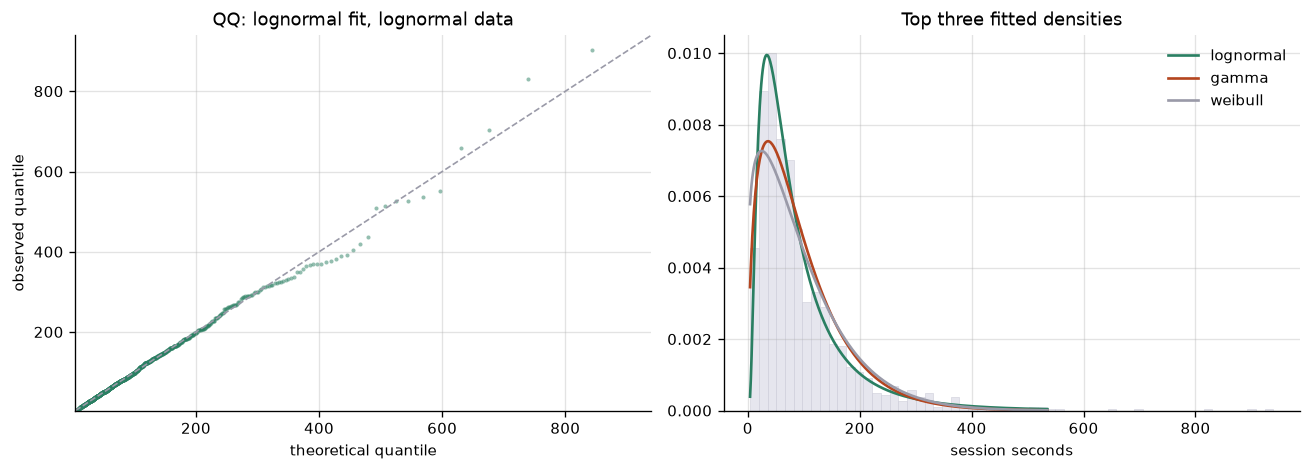

In [4]:
x = book["session_seconds"]
fam = family("lognormal")
params = fit_params(fam, x)
theo, emp = qq_points(fam, x, params)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lo, hi = float(emp.min()), float(emp.max())
axes[0].plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1)
axes[0].scatter(theo, emp, s=6, color=PASS, alpha=0.5, linewidths=0)
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_title("QQ: lognormal fit, lognormal data")
axes[0].set_xlabel("theoretical quantile"); axes[0].set_ylabel("observed quantile")

axes[1].hist(x, bins=60, density=True, color="#e6e6ee", edgecolor="#c9c9d6", lw=0.3)
grid = np.linspace(x.min(), np.percentile(x, 99.5), 400)
for name, colour in (("lognormal", PASS), ("gamma", FAIL), ("weibull", MUTED)):
    f = family(name)
    axes[1].plot(grid, f.dist.pdf(grid, *fit_params(f, x)), color=colour, lw=1.6, label=name)
axes[1].legend(frameon=False)
axes[1].set_title("Top three fitted densities"); axes[1].set_xlabel("session seconds")
plt.tight_layout(); plt.show()

## 2. The main event: the KS p-value is wrong when you fit the parameters first

Look at the `p naive` column in the table above. Every rejected family has `p naive = 0.000`,
which looks decisive. Now look at the winning row: `p naive` is around **0.90**.

That number is not a 90% chance the data is lognormal, and it is not even a correctly
calibrated p-value. `scipy.stats.ks_1samp(x, dist.cdf, args=fitted_params)` computes the KS
distance between the data and a CDF **that was chosen to be close to that data**, then
compares it against a reference distribution that assumes the parameters were fixed in
advance. The estimation shrinks the distance; the reference does not know that.

The consequence is measurable. Simulate 200 datasets **from the family being tested**, so the
null hypothesis is true by construction. A correctly calibrated test rejects 5% of the time
and its p-values are uniform on [0, 1], averaging 0.5.

In [5]:
from evidence import ks_calibration, ks_power, calibration_table

cal_true = ks_calibration("normal", n=200, n_datasets=200, n_boot=150, seed=11)
cal_ln = ks_calibration("lognormal", n=200, n_datasets=120, n_boot=150, seed=12)
print(calibration_table([cal_true, cal_ln]))

setting                         n  reject naive   reject boot   mean p nv   mean p bt
-------------------------------------------------------------------------------------
normal (null is true)         200         0.000         0.025       0.806       0.533
lognormal (null is true)      200         0.000         0.033       0.780       0.473
-------------------------------------------------------------------------------------
rows 1-2: null TRUE, target = alpha. rows 3+: null FALSE, higher is better.


The naive test rejects **essentially never**, and its p-values average around 0.8 instead
of 0.5. That is not conservatism you can bank - it is the estimation shrinkage showing up as
fake evidence *in favour of* the null, and a test that never rejects a true null has no power
left for a false one.

The fix is a parametric bootstrap, and the whole content of the fix is one word: **refit**.

```python
for b in range(B):
    xs      = dist.rvs(*fitted_params, size=n)   # simulate from the fitted model
    fit_b   = dist.fit(xs)                       # <-- refit, on the simulated sample
    D_b     = ks_distance(xs, dist.cdf, fit_b)   # this D enjoys the same shrinkage
```

Simulating and then comparing against the *original* fitted CDF reproduces the textbook null
and is just as wrong. Refitting each replicate reproduces the shrinkage the observed distance
also got, which is what makes the two comparable. (This is the Lilliefors construction,
generalised past the normal.)

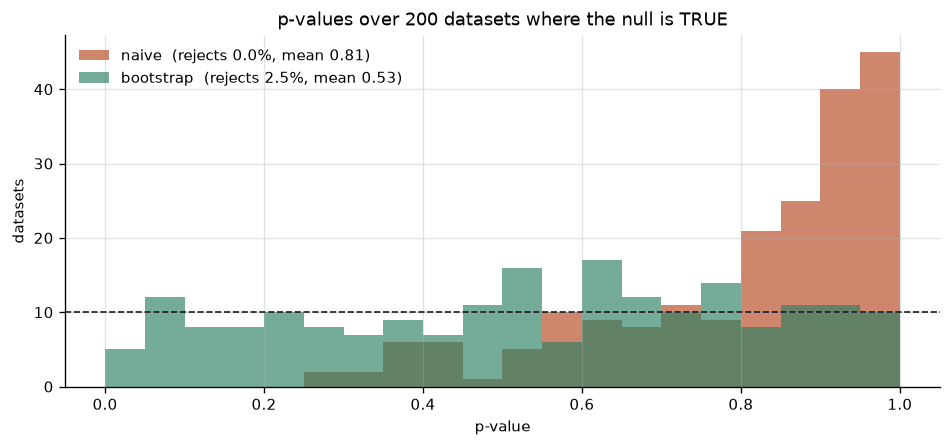

In [6]:
bins = np.linspace(0, 1, 21)
p_naive, p_boot = cal_true.p_naive_all, cal_true.p_bootstrap_all

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(p_naive, bins=bins, color=FAIL, alpha=0.65,
        label=f"naive  (rejects {np.mean(p_naive < 0.05):.1%}, mean {p_naive.mean():.2f})")
ax.hist(p_boot, bins=bins, color=PASS, alpha=0.65,
        label=f"bootstrap  (rejects {np.mean(p_boot < 0.05):.1%}, mean {p_boot.mean():.2f})")
ax.axhline(len(p_naive) / 20, color="#1b1b1f", ls="--", lw=1)
ax.set_title("p-values over 200 datasets where the null is TRUE")
ax.set_xlabel("p-value"); ax.set_ylabel("datasets")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

The dashed line is what a flat (correctly calibrated) histogram would look like. The green
bars are roughly flat. The red bars are stacked against the right edge.

Losing the false-null case is the part that costs money. Same machinery, data now drawn from a
Student-t while a normal is fitted, so rejection is the right answer:

In [7]:
pw = ks_power("normal", "student_t", n=400, n_datasets=100, n_boot=150, seed=13)
print(calibration_table([cal_true, pw]))

setting                         n  reject naive   reject boot   mean p nv   mean p bt
-------------------------------------------------------------------------------------
normal (null is true)         200         0.000         0.025       0.806       0.533
normal on student_t data      400         0.530         0.970       0.088       0.013
-------------------------------------------------------------------------------------
rows 1-2: null TRUE, target = alpha. rows 3+: null FALSE, higher is better.


## 3. AIC's confident winner on data no candidate can describe

`latency_ms` is a two-component mixture: a fast path and a slow path. No single-family fit can
represent that, and the candidate list contains no mixtures.

AIC does not care. It ranks what it was given and reports a winner with an Akaike weight of
1.00 - the same output shape it produced in section 1, when the answer was right.

In [8]:
rep_mix = fit_distributions(book["latency_ms"], n_boot=200, stability_reps=100, seed=17,
                            probe_location=False)
print(rep_mix.table())
print()
print(rep_mix.verdict())

family        k      logLik         AIC     dAIC  weight    KS D  p naive  p boot   win%
----------------------------------------------------------------------------------------
student_t     3    -5287.23    10580.45     0.00   1.000  0.1459    0.000   0.005   100% *
lognormal     2    -5533.77    11071.54   491.09   0.000  0.2262    0.000   0.005     0% *
pareto        2    -5625.28    11254.57   674.11   0.000  0.2954    0.000   0.005     0% *
weibull       2    -5899.23    11802.47  1222.01   0.000  0.2785    0.000   0.005     0% *
gamma         2    -5942.06    11888.13  1307.67   0.000  0.3266    0.000   0.005     0% *
exponential   1    -5945.05    11892.11  1311.65   0.000  0.3394    0.000   0.005     0% *
logistic      2    -6753.48    13510.97  2930.51   0.000  0.3242    0.000   0.005     0% *
normal        2    -7233.27    14470.54  3890.08   0.000  0.4053    0.000   0.005     0% *
uniform       2    -8414.11    16832.21  6251.76   0.000  0.8317    0.000   0.005     0% *
---

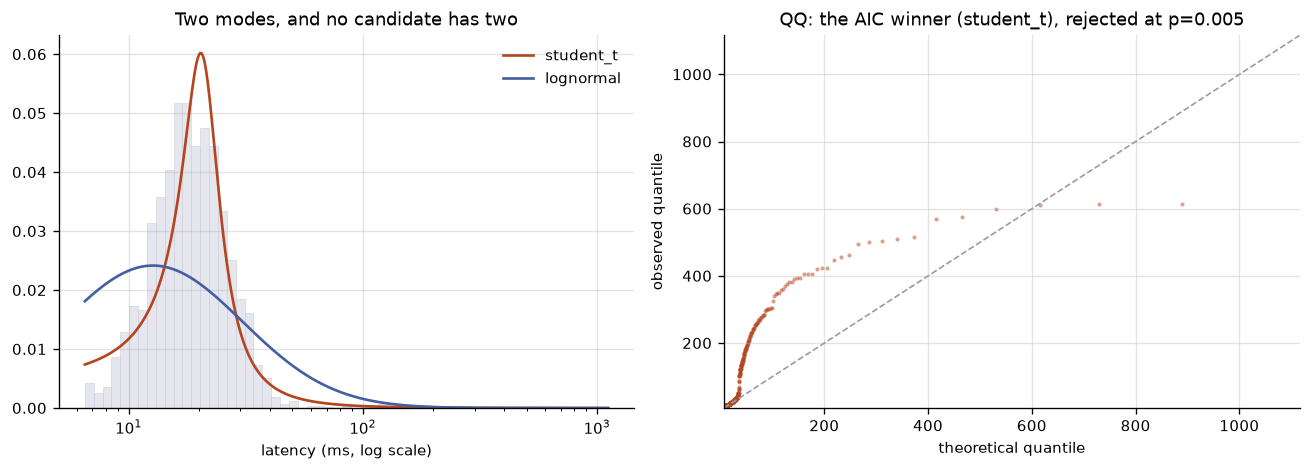

In [9]:
x = book["latency_ms"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 60)
axes[0].hist(x, bins=bins, density=True, color="#e6e6ee", edgecolor="#c9c9d6", lw=0.3)
grid = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
for name, colour in ((rep_mix.best.name, FAIL), ("lognormal", ACCENT)):
    f = family(name)
    axes[0].plot(grid, f.dist.pdf(grid, *fit_params(f, x)), color=colour, lw=1.6, label=name)
axes[0].set_xscale("log"); axes[0].legend(frameon=False)
axes[0].set_title("Two modes, and no candidate has two")
axes[0].set_xlabel("latency (ms, log scale)")

best = rep_mix.best
theo, emp = qq_points(best.family, x, best.params)
lo, hi = float(emp.min()), float(emp.max())
axes[1].plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1)
axes[1].scatter(theo, emp, s=6, color=FAIL, alpha=0.5, linewidths=0)
axes[1].set_xlim(lo, hi); axes[1].set_ylim(lo, hi)
axes[1].set_title(f"QQ: the AIC winner ({best.name}), rejected at p={best.ks.p_bootstrap:.3f}")
axes[1].set_xlabel("theoretical quantile"); axes[1].set_ylabel("observed quantile")
plt.tight_layout(); plt.show()

**The AIC column cannot tell these two cases apart.** Section 1 and section 3 both produce a
winner with weight 1.00 and a 100% bootstrap win share. The only column that separates "this is
the distribution" from "this is the nearest thing in a list that does not contain the
distribution" is the absolute test.

That is why the tool prints `NO ADEQUATE FIT` rather than a winner, and why the winner is still
shown underneath it: least-bad is genuinely useful, as long as it is labelled.

### What "no adequate fit" costs downstream

A fitted distribution is not the deliverable. The deliverable is a number read off its tail: a
p99 for an SLA, a p99.9 for capacity, a VaR, a simulation input. The tail is the part of the fit
the body of the data constrains least, so this is exactly where "least-bad" stops being harmless.

In [10]:
from evidence import tail_error, tail_table

print(tail_table(tail_error()))

family                         p99       err       p99.9       err
------------------------------------------------------------------
student_t   AIC winner       355.7      -30%      5577.3     +490%
lognormal                    214.8      -58%       421.2      -55%
weibull                      280.1      -45%       452.9      -52%
gamma                        250.9      -51%       380.1      -60%
------------------------------------------------------------------
empirical p99 = 510.4, empirical p99.9 = 944.7


Every candidate understates the p99 by 30-58%. Then the AIC winner turns around and
**overstates the p99.9 by nearly 6x**, while the others understate it by half.

There is no safe direction to round, and no constant to multiply by. An SLA set from the winning
fit would be simultaneously too aggressive at p99 and absurdly slack at p99.9 - and nothing in
the AIC table, the weight, or the win share would have warned you. Only the absolute test does.

## 4. Support is a constraint, not a nuisance

`daily_return` has 481 negative values. A lognormal cannot describe it - not "fits badly",
*cannot*, because the density is zero below the origin.

The tempting move is to drop the offending rows and fit anyway. That silently changes the
dataset, and an AIC computed on 419 rows is not comparable to one computed on 900. So
out-of-support families are excluded with a reason instead.

In [11]:
rep_ret = fit_distributions(book["daily_return"], n_boot=200, stability_reps=100, seed=19,
                            probe_location=False)
print(rep_ret.table())
print()
print(rep_ret.verdict())

family        k      logLik         AIC     dAIC  weight    KS D  p naive  p boot   win%
----------------------------------------------------------------------------------------
student_t     3     2549.55    -5093.11     0.00   0.999  0.0202    0.849   0.308    96%
logistic      2     2541.90    -5079.80    13.31   0.001  0.0281    0.466   0.015     4% *
normal        2     2496.21    -4988.41   104.70   0.000  0.0658    0.001   0.005     0% *
uniform       2     1662.54    -3321.08  1772.03   0.000  0.3918    0.000   0.005     0% *
----------------------------------------------------------------------------------------
* rejected by the bootstrap KS test at alpha=0.05
excluded: lognormal    481 value(s) <= 0; support is x > 0
excluded: gamma        481 value(s) <= 0; support is x > 0
excluded: weibull      481 value(s) <= 0; support is x > 0
excluded: exponential  481 value(s) <= 0; support is x > 0
excluded: pareto       481 value(s) <= 0; support is x > 0
excluded: beta         481

Note the second row. `logistic` is rejected by the bootstrap test at p = 0.02 while its
naive p-value is around 0.47 - a family that a conventional goodness-of-fit check would have
kept for a returns model, where the tail is the entire point.

## 5. What a free location parameter actually buys

`lognorm.fit(x)` estimates three parameters, not two: shape, **loc**, and scale. Positive-support
families here are fit with `floc=0`, and that choice is worth defending.

Below: data generated from `gamma(2.4, scale=18)` with **loc = 0**, so the third parameter has
nothing to find.

In [12]:
from evidence import free_location_cost, location_table

print(location_table(free_location_cost(n=1200, seed=31)))

family      role             dlogLik     AIC pin    AIC free   loc hat    min(x) AIC pick
-----------------------------------------------------------------------------------------
gamma       true family         0.00     11107.4     11109.4     0.044     1.668   pinned
lognormal   wrong family       45.22     11223.7     11135.3   -13.370     1.668     free
weibull     wrong family        -inf     11112.4         inf     2.876     1.668  INVALID
-----------------------------------------------------------------------------------------
data is gamma(2.4, 18) with loc = 0; the third parameter has nothing to find. INVALID = fitted loc exceeds min(x), so observed points have zero density.


Three different failures, none of them "it recovers zero":

- **gamma** is the true family. The free parameter buys ~0 log-likelihood, so AIC's +2 penalty
  correctly rejects it. This is the case the textbook describes.
- **lognormal** is a wrong family, and the shift lets it imitate a gamma - so it gains a large
  amount of log-likelihood and its 3-parameter version beats its own 2-parameter version by a
  wide AIC margin. **The reward for the extra parameter scales with how wrong the family is**,
  which is precisely backwards in a contest meant to identify the right one.
- **weibull** is worse than either. The 3-parameter MLE is unbounded as `loc` approaches
  `min(x)` from below, the optimiser walks toward that singularity and steps over it, and scipy
  returns a `loc` **above** the smallest observation. Observed data points then have zero
  density under the fitted model and the log-likelihood is `-inf`. It is not a bad fit; it is
  not a probability model for this data at all.

Mixing pinned and unpinned fits in one AIC table scores all three of these against each other
as though they were comparable.

## 6. Rounding, sample size, and rejecting the true family

Every real measurement is rounded. Prices to cents, durations to milliseconds, ages to years.
Rounding makes the data discrete, which makes the empirical CDF a step function with visible
jumps, which inflates the KS distance for reasons that have nothing to do with shape.

Below, the data is **genuinely normal in every row**. Only `n` and the rounding change.

In [13]:
from evidence import rounding_vs_n, rounding_table

sizes = (100, 400, 1600, 6400, 20000)
print(rounding_table(rounding_vs_n(sizes=sizes, decimals=1, n_boot=200, seed=29)))

       n  round      ties      KS D     p boot  verdict
-------------------------------------------------------
     100    1dp     0.630    0.0887      0.085     keep
     400    1dp     0.877    0.0378      0.169     keep
    1600    1dp     0.963    0.0399      0.005   REJECT
    6400    1dp     0.989    0.0234      0.005   REJECT
   20000    1dp     0.996    0.0220      0.005   REJECT
-------------------------------------------------------
data is genuinely normal in every row; only n and the rounding differ


And the control - the same sizes, unrounded:

In [14]:
print(rounding_table(rounding_vs_n(sizes=sizes, decimals=None, n_boot=200, seed=29)))

       n  round      ties      KS D     p boot  verdict
-------------------------------------------------------
     100    raw     0.000    0.0860      0.090     keep
     400    raw     0.000    0.0302      0.478     keep
    1600    raw     0.000    0.0220      0.095     keep
    6400    raw     0.000    0.0063      0.831     keep
   20000    raw     0.000    0.0052      0.254     keep
-------------------------------------------------------
data is genuinely normal in every row; only n and the rounding differ


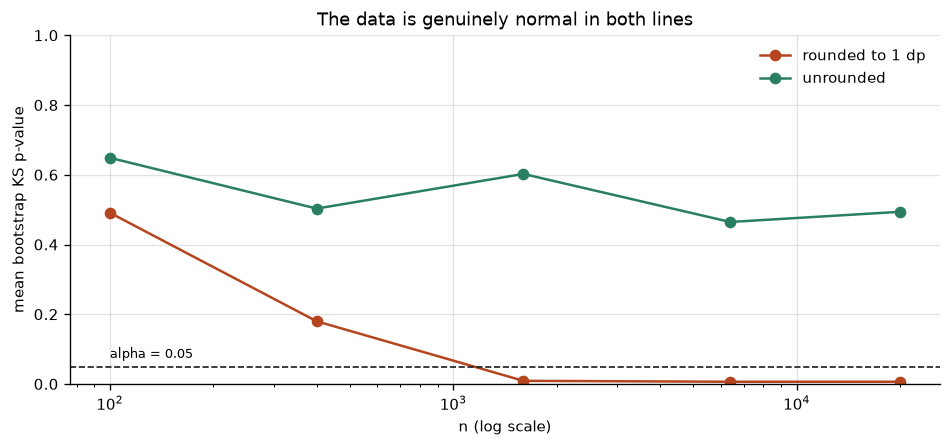

averaged over 5 independent datasets per point - a single dataset per
point would plot uniform noise, because that is what a p-value under a true null is


In [15]:
seeds = (29, 131, 233, 337, 439)
def mean_curve(decimals):
    out = []
    for n in sizes:
        vals = [rounding_vs_n(sizes=(n,), decimals=decimals, n_boot=150, seed=s)[0].p_bootstrap
                for s in seeds]
        out.append(float(np.mean(vals)))
    return out

rounded_curve, raw_curve = mean_curve(1), mean_curve(None)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(sizes, rounded_curve, marker="o", color=FAIL, lw=1.5, label="rounded to 1 dp")
ax.plot(sizes, raw_curve, marker="o", color=PASS, lw=1.5, label="unrounded")
ax.axhline(0.05, color="#1b1b1f", ls="--", lw=1)
ax.text(sizes[0], 0.075, "alpha = 0.05", fontsize=8)
ax.set_xscale("log"); ax.set_ylim(0, 1)
ax.set_xlabel("n (log scale)"); ax.set_ylabel("mean bootstrap KS p-value")
ax.set_title("The data is genuinely normal in both lines")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print("averaged over", len(seeds), "independent datasets per point - a single dataset per")
print("point would plot uniform noise, because that is what a p-value under a true null is")

The red line crosses alpha somewhere around n = 1600 and never comes back. Nothing about
the data's shape changed; the reference distribution shrank like 1/sqrt(n) while the rounding
artefact stayed put.

This is not a bug in the test. It is the test correctly answering a question nobody wanted to
ask. Past a few thousand rows, "is this exactly normal" is always answerable and always no. The
useful question becomes "is the departure big enough to matter for the decision downstream",
which is a question about your loss function, not about a p-value.

Hence the tie diagnostic, which runs before any of this:

In [16]:
for name in ("session_seconds", "basket_value", "latency_ms"):
    print(name)
    print(diagnose(book[name]).describe())
    print()

session_seconds
n = 1200,  unique = 1200,  tie fraction = 0.000
range = [4.092, 939.3],  values <= 0: 0
skew = +3.261,  excess kurtosis = +17.830

basket_value
n = 1200,  unique = 1124,  tie fraction = 0.063
range = [1.76, 170.7],  values <= 0: 0
skew = +1.032,  excess kurtosis = +1.090
values are rounded to 2 decimal place(s) - the data is discrete, every continuous fit is an approximation

latency_ms
n = 1200,  unique = 452,  tie fraction = 0.623
range = [6.5, 1116],  values <= 0: 0
skew = +4.580,  excess kurtosis = +27.473
values are rounded to 1 decimal place(s) - the data is discrete, every continuous fit is an approximation



## 7. Akaike weight vs bootstrap selection stability

The Akaike weight is a transformation of one dataset's delta-AIC. It is routinely read as "the
probability this is the best model", but it is computed from the single delta you happened to
observe, on the single sample you happened to draw.

The bootstrap win share measures the same intent directly: resample the rows, rerun the entire
comparison, count how often each family comes first.

In [17]:
from evidence import stability_vs_n, stability_table

rows = stability_vs_n(true_family="gamma",
                      rivals=("gamma", "lognormal", "weibull", "normal"),
                      sizes=(100, 400, 1600, 6400), reps=100, seed=23)
print(stability_table(rows))

      n  AIC winner   dAIC(true)    w(true)   win%(true) win%(winner)
---------------------------------------------------------------------
    100  gamma              0.00      0.719          44%          44%
    400  weibull            1.41      0.331          38%          62%
   1600  gamma              0.00      0.999          87%          87%
   6400  gamma              0.00      1.000         100%         100%
---------------------------------------------------------------------
true family = gamma; win shares over 100 nonparametric bootstrap resamples


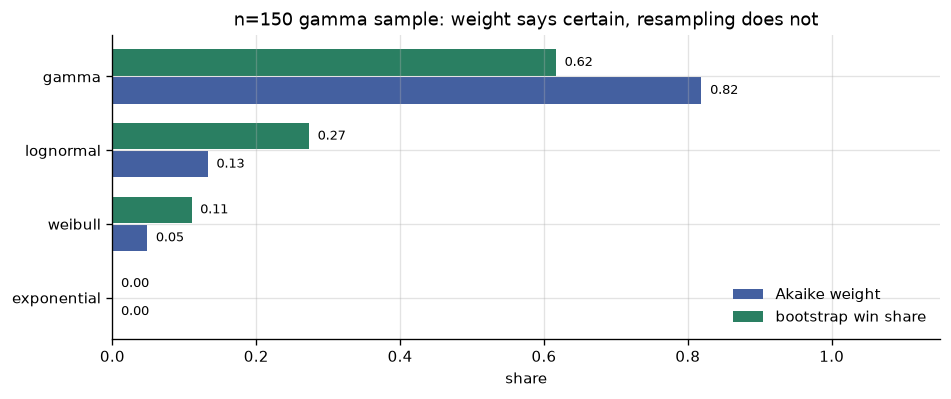

In [18]:
small = np.random.default_rng(41).gamma(2.4, 18.0, 150)
rep_small = fit_distributions(
    small, families=[family(n) for n in ("gamma", "lognormal", "weibull", "exponential")],
    n_boot=0, stability_reps=300, seed=41, probe_location=False)

ranked = rep_small.ranked
names = [r.name for r in ranked]
idx = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(idx + 0.19, [r.aic_weight for r in ranked], height=0.36, color=ACCENT,
        label="Akaike weight")
ax.barh(idx - 0.19, [r.win_share for r in ranked], height=0.36, color=PASS,
        label="bootstrap win share")
for i, r in enumerate(ranked):
    ax.text(r.aic_weight + 0.012, i + 0.19, f"{r.aic_weight:.2f}", va="center", fontsize=8)
    ax.text(r.win_share + 0.012, i - 0.19, f"{r.win_share:.2f}", va="center", fontsize=8)
ax.set_yticks(idx); ax.set_yticklabels(names); ax.invert_yaxis(); ax.set_xlim(0, 1.15)
ax.set_xlabel("share"); ax.set_title("n=150 gamma sample: weight says certain, resampling does not")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

On this n=150 gamma sample the Akaike weight puts **0.82** on gamma; resampling the rows has
gamma actually winning **0.62** of the time. Twenty points of confidence that only exists because
the delta was computed once.

The two numbers converge as n grows - which is the point. The weight does not shrink its own
confidence when the sample is small; the bootstrap does it for you.

The n=400 row of the table above is the sharper case: the AIC winner there is **weibull**, with
the true gamma trailing by dAIC = 1.41. Under the usual "delta-AIC below 2 means indistinguishable"
convention that is a tie you would report as a tie. The win shares say something more useful -
neither family holds a majority, so there is no winner to report at all.

## 8. The verdict

Putting the whole thing together on all four sample columns. Note that the four verdicts are
genuinely different sentences, not four copies of one template with the family name swapped.

In [19]:
for name, col in book.items():
    r = fit_distributions(col, n_boot=200, stability_reps=100, seed=2, probe_location=False)
    print("=" * 88)
    print(f"{name}  (n={r.diagnostics.n})")
    print("-" * 88)
    print(r.verdict())
    print()

session_seconds  (n=1200)
----------------------------------------------------------------------------------------
`lognormal` wins on AIC and survives the bootstrap KS test (p=0.652). That is the strongest claim this tool makes: not rejected, on this sample size. The winner is stable: top rank in 100% of 100 bootstrap resamples.

basket_value  (n=1200)
----------------------------------------------------------------------------------------
`gamma` wins on AIC and survives the bootstrap KS test (p=0.303). That is the strongest claim this tool makes: not rejected, on this sample size. The winner is stable: top rank in 86% of 100 bootstrap resamples. Ties are heavy enough to inflate every KS statistic here; treat the absolute tests as advisory and the ranking as the usable output.

latency_ms  (n=1200)
----------------------------------------------------------------------------------------
NO ADEQUATE FIT. Every candidate is rejected by the bootstrap KS test at alpha=0.05. `student_t` is

| column | truth | what the tool says |
|---|---|---|
| `session_seconds` | lognormal | lognormal, not rejected, stable |
| `basket_value` | gamma, rounded to cents | gamma, not rejected, with a ties warning |
| `latency_ms` | two-component mixture | **no adequate fit**, winner labelled least-bad |
| `daily_return` | Student-t | student_t, not rejected; normal rejected |

Four different answers, and the one that matters most is the one that refuses to name a
distribution.

## 9. Try your own column

Uncomment, point it at your own data, and read the verdict before the table.

In [20]:
# import pandas as pd
# frame = pd.read_csv("your_data.csv")
# x = frame["your_column"].dropna().to_numpy(dtype=float)
#
# report = fit_distributions(
#     x,
#     n_boot=300,          # resolution of the absolute test; min p is 1/(B+1)
#     stability_reps=200,  # resolution of the win shares
#     alpha=0.05,
#     seed=0,
# )
# print(report.diagnostics.describe())   # check the ties BEFORE reading any p-value
# print()
# print(report.table())
# print()
# print(report.verdict())
#
# Three things to read, in this order:
#   1. tie fraction   - heavy ties invalidate the absolute tests before you start
#   2. the verdict    - is ANY candidate not rejected, or is the winner just least-bad
#   3. win share      - would the winner win again on resampled rows
# The AIC column is the last thing to look at, not the first.
print("ready - uncomment the block above and point it at your own CSV")

ready - uncomment the block above and point it at your own CSV


---

## What to take away

1. **AIC ranks; it does not test.** A winner is produced whether or not the candidate set
   contains the answer. Always pair the ranking with an absolute goodness-of-fit test.
2. **A KS p-value computed on fitted parameters is not a KS p-value.** Over 200 true-null
   datasets it rejected 0% of the time and averaged 0.79 instead of 0.5. Refit inside a
   parametric bootstrap; the fix is one line and it restores both calibration and power.
3. **Support violations are exclusions, not filters.** Fitting a family to the subset of rows
   it can describe puts its AIC on a different dataset from every other candidate's.
4. **A free location parameter rewards the wrong family more than the right one**, and its MLE
   is unbounded at `min(x)` - scipy will hand back fits that assign zero density to observed
   points.
5. **Past a few thousand rows, everything is rejected, including the truth.** Measure the ties
   first and treat "is this exactly parametric" as a question about n.

## Run the code

```bash
git clone https://github.com/phoebefu6/phoebe-the-builder
cd phoebe-the-builder/data-science-cookbook/distribution-fitter
pip install -r requirements.txt

python3 test_fitting.py     # 21 tests over the fitting core
python3 test_evidence.py    #  9 tests over the experiments above
python3 make_chart.py       # the six-panel audit figure
streamlit run app.py        # the interactive version
```

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 136,
Data Science Cookbook.